In [104]:
import pandas as pd
import numpy as np
import seaborn as sns
from xml.etree import ElementTree as ET
import matplotlib.pyplot as plt

import re
# 한글 폰트 설정 (Mac)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [ ]:
# data.go.kr API 사용하기
# 비급여 진료비 정보 조회 API

import requests

# API 키 (Decoding 버전)
SERVICE_KEY = ''

url = 'http://apis.data.go.kr/B551182/nonPaymentDamtInfoService/getNonPaymentItemHospDtlList'
params = {
    'serviceKey': SERVICE_KEY, 
    'pageNo': '1', 
    'numOfRows': '10000',  # 2개에서 10개로 늘림
    'clCd': '',
    'sidoCd': '110000', 
    'sgguCd': '', 
    'yadmNm': ''
}

response = requests.get(url, params=params)
print(f"Status Code: {response.status_code}")
print(f"\nResponse:\n{response.text[:1000]}")  # 처음 1000자 출력

# XML 파싱
root = ET.fromstring(response.content)

Status Code: 200

Response:
<?xml version="1.0" encoding="UTF-8" standalone="yes"?><response><header><resultCode>00</resultCode><resultMsg>NORMAL SERVICE.</resultMsg></header><body><items><item><adtEndDd>99991231</adtEndDd><adtFrDd>20251118</adtFrDd><clCd>21</clCd><clCdNm>병원</clCdNm><curAmt>680000</curAmt><npayCd>HE1150000</npayCd><npayKorNm>자기공명영상진단료(MRI-기본검사)/근골격계-견관절/일반</npayKorNm><sgguCd>110001</sgguCd><sgguCdNm>강남구</sgguCdNm><sidoCd>110000</sidoCd><sidoCdNm>서울</sidoCdNm><sno>9</sno><yadmNm>하병원</yadmNm><yadmNpayCdNm>MRI Shoulder</yadmNpayCdNm><ykiho>JDQ4MTg4MSM1MSMkMSMkMCMkOTkkMzgxMzUxIzUxIyQxIyQxIyQ3OSQ0NjE0ODEjNTEjJDEjJDIjJDgz</ykiho></item><item><adtEndDd>99991231</adtEndDd><adtFrDd>20251118</adtFrDd><clCd>21</clCd><clCdNm>병원</clCdNm><curAmt>680000</curAmt><npayCd>HE1170000</npayCd><npayKorNm>자기공명영상진단료(MRI-기본검사)/근골격계-수관절/일반</npayKorNm><sgguCd>110001</sgguCd><sgguCdNm>강남구</sgguCdNm><sidoCd>110000</sidoCd><sidoCdNm>서울</sidoCdNm><sno>31</sno><yadmNm>하병원</yadmNm><yadmNpayCdNm>MRI LT

In [86]:
# 데이터 추출
data_list = []
for item in root.findall('.//item'):
    data_dict = {}
    for child in item:
        data_dict[child.tag] = child.text
    data_list.append(data_dict)

# DataFrame 생성
df_seoul = pd.DataFrame(data_list)
print(f"총 {len(df)}개의 데이터\n")
df_seoul.to_csv("df_seoul.csv", index=False)

총 10000개의 데이터



In [84]:
# DataFrame 생성
df_busan= pd.DataFrame(data_list)
print(f"총 {len(df)}개의 데이터\n")
df_busan.to_csv("df_busan.csv", index=False)

총 10000개의 데이터



## API 파라미터 정보

| 파라미터 | 설명 | 길이 | 필수 여부 | 샘플 데이터 | 비고 |
|---------|------|------|-----------|------------|------|
| **ykiho** | 암호화된 요양기관기호 | 8 | 0 | JDQ4MTg4MSM1MSM1MkMkMzMw... | 암호화된 요양기관기호 |
| **yadmNm** | 병원명 | 200 | 0 | 중앙대학교병원 | 병원명 |
| **clCd** | 종별코드 | 2 | 0 | 01 | 종별코드 |
| **clCdNm** | 종별코드명 | 50 | 0 | 상급종합 | 종별코드명 |
| **sidoCd** | 시도코드 | 6 | 0 | 110000 | 시도코드 |
| **sidoCdNm** | 시도명 | 40 | 0 | 서울 | 시도명 |
| **sgguCd** | 시군구코드 | 6 | 0 | 110008 | 시군구코드 |
| **sgguCdNm** | 시군구명 | 40 | 0 | 동작구 | 시군구명 |
| **urlAddr** | URL주소 | 500 | 0 | http://ch.cauhs.or.kr/... | URL주소 |
| **sno** | 일련번호 | 7 | 0 | 240 | 일련번호 |
| **npayCd** | 비급여코드 | 50 | 0 | HE1180000 | 비급여코드 |
| **npayKorNm** | 비급여한글명 | 400 | 0 | MRI(뇌/두부/척추/고관절/사관절) | 비급여한글명 |
| **yadmNpayCdNm** | 요양기관비급여코드명 | 400 | 0 | Hip MRI | 요양기관비급여코드명 |
| **adtFrDd** | 적용개시일자 | 8 | 0 | 20180402 | 적용개시일자 |
| **adtEndDd** | 적용종료일자 | 8 | 0 | 99991231 | 적용종료일자 |

### 참고사항
- **필수 여부**: 0 = 선택, 1 = 필수
- **clCd (종별코드)**: 01 = 상급종합
- **sidoCd**: 110000 = 서울
- **sgguCd**: 110008 = 동작구
- **ykiho**: 요양기관기호는 암호화되어 제공됨

In [ ]:
df_seoul.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   adtEndDd      10000 non-null  object
 1   adtFrDd       10000 non-null  object
 2   clCd          10000 non-null  object
 3   clCdNm        10000 non-null  object
 4   curAmt        10000 non-null  object
 5   npayCd        10000 non-null  object
 6   npayKorNm     10000 non-null  object
 7   sgguCd        10000 non-null  object
 8   sgguCdNm      10000 non-null  object
 9   sidoCd        10000 non-null  object
 10  sidoCdNm      10000 non-null  object
 11  sno           10000 non-null  object
 12  urlAddr       10000 non-null  object
 13  yadmNm        10000 non-null  object
 14  yadmNpayCdNm  10000 non-null  object
 15  ykiho         10000 non-null  object
dtypes: object(16)
memory usage: 1.2+ MB


In [ ]:
# drop
df_seoul.drop(['clCd', 'yadmNpayCdNm', 'urlAddr','sidoCd','sgguCd','sno','ykiho','adtEndDd','npayCd'], axis=1, inplace=True)
df_busan.drop(['clCd', 'yadmNpayCdNm', 'urlAddr','sidoCd','sgguCd','sno','ykiho','adtEndDd','npayCd'], axis=1, inplace=True)

df_seoul['curAmt'] = pd.to_numeric(df_seoul['curAmt'])
df_busan['curAmt'] = pd.to_numeric(df_busan['curAmt'])

In [88]:
df_seoul.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   adtFrDd    10000 non-null  object
 1   clCdNm     10000 non-null  object
 2   curAmt     10000 non-null  int64 
 3   npayKorNm  10000 non-null  object
 4   sgguCdNm   10000 non-null  object
 5   sidoCdNm   10000 non-null  object
 6   yadmNm     10000 non-null  object
dtypes: int64(1), object(6)
memory usage: 547.0+ KB


# 예1. 도수치료

npayKorNm
이학요법료/도수치료    326
Name: count, dtype: int64
도수치료 평균가:  159864.0

clCdNm
병원      172093.0
상급종합     70500.0
요양병원    137683.0
종합병원    105465.0
한방병원    165450.0
Name: curAmt, dtype: float64


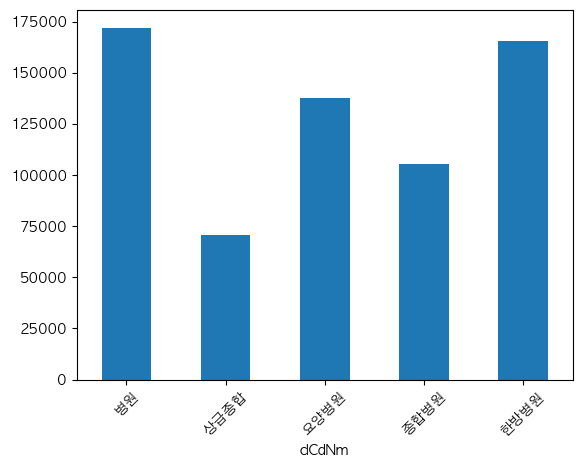

In [ ]:
# 도수치료가 들어간 것들은 보통 얼마하는가?
# 서울
dosu_seoul = df_seoul[df_seoul['npayKorNm'].str.contains('도수', na=False)]
print(dosu_seoul['npayKorNm'].value_counts()) # 비급여 항목도 같음
print("도수치료 평균가: ", round(dosu_seoul['curAmt'].mean(),0))
print("")
print(round(dosu_seoul.groupby('clCdNm')['curAmt'].mean(),0))

dosu_seoul.groupby('clCdNm')['curAmt'].mean().plot(kind='bar')
plt.xticks(rotation=45)
plt.show()

왜 종별에 따라 가격이 다를까

npayKorNm
이학요법료/도수치료    325
Name: count, dtype: int64
도수치료 평균가:  99156.0

clCdNm
병원       97674.0
상급종합     76400.0
요양병원     38415.0
종합병원     88760.0
한방병원    153459.0
Name: curAmt, dtype: float64


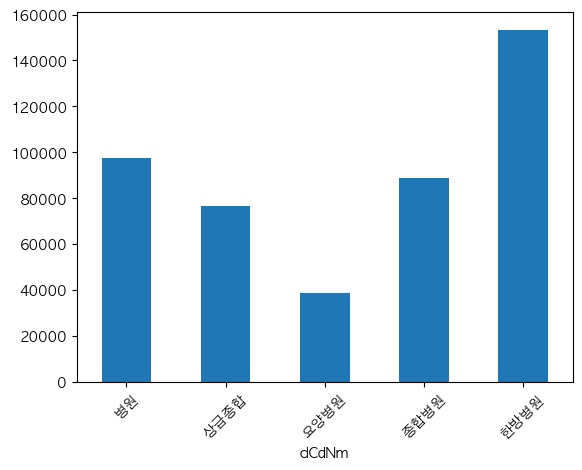

In [106]:
# 도수치료가 들어간 것들은 보통 얼마하는가?
# 부산
dosu_busan = df_busan[df_busan['npayKorNm'].str.contains('도수', na=False)]
print(dosu_busan['npayKorNm'].value_counts()) # 비급여 항목도 같음
print("도수치료 평균가: ", round(dosu_busan['curAmt'].mean(),0))
print("")
print(round(dosu_busan.groupby('clCdNm')['curAmt'].mean(),0))

dosu_busan.groupby('clCdNm')['curAmt'].mean().plot(kind='bar')
plt.xticks(rotation=45)
plt.show()

비급여 항목 중 하나인 도수치료의 경우 지역마다 가격이 다르고, 종별에 따라 가격이 다르다.
그리고 비급여는 한방병원에서 많은 비용이 나온다. 비급여 항목은 병원에서 가격을 정하기 때문에 차이가 나는 것이다.

- 한방병원만 가는 걸 고집하는 사람은? 
- 집에서 가까운 거리에 병원이 있는데도 한방병원으로 가는 건 아닌지?
- 일부 병원에서 높은 가격이 책정되어 있으니, 환자와 병원이 결탁되어 불필요한 치료를 받거나, 미용 목적 시술을 도수치료로 하는 경우도 있지 않을까?

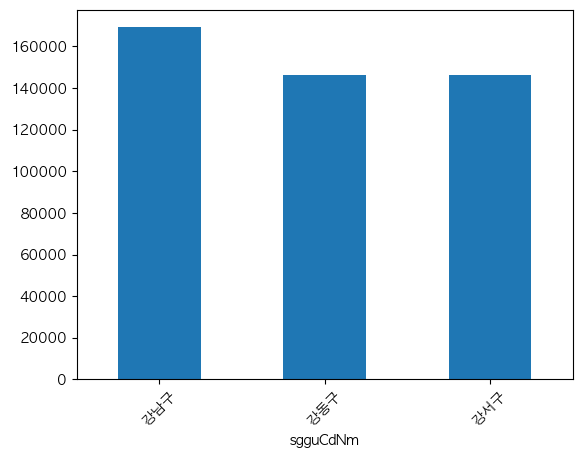

In [110]:
#강남구, 강서구 구까지도 차이가 날까?

dosu_seoul.groupby('sgguCdNm')['curAmt'].mean().plot(kind='bar')
plt.xticks(rotation=45)
plt.show()

# 가장 비싼 비급여 항목은 뭘까?